# 01-Exploratory Data Analysis
# Explore the raw credit dataset: shape, types, missing values, target balance, and relationships between financial features and default risk.

In [23]:
import sys
sys.path.append("..")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [24]:
from src.utils import RAW_DATA_PATH,TARGET_COLUMN
from src.preprocessing import load_raw_data
sns.set_style('whitegrid')
%matplotlib inline

In [25]:
df = load_raw_data(RAW_DATA_PATH)
df.head()

2026-07-08 17:34:06 | INFO     | src.preprocessing | Loading raw data from C:\Users\mohit\Credit-scoring-model\data\raw\credit_data.csv
2026-07-08 17:34:06 | INFO     | src.preprocessing | Loaded 1000 rows, 21 columns


,status_account,month_duration,credit_history,purpose,credit_amount,status_savings,years_employment,payment_to_income_ratio,status_and_sex,secondary_obligor,...,collateral,age,other_installment_plans,housing,n_credits,job,n_guarantors,telephone,is_foreign_worker,target
0,< 0 DM,6,critical account/ other credits existing (not ...,radio/television,1169,unknown/ no savings account,>= 7 years,4,male : single,none,...,none,67,none,own,2,skilled employee/ official,1,"yes, registered under the customers name",yes,good
1,0 to < 200 DM,48,existing credits paid back duly till now,radio/television,5951,< 100 DM,1 to < 4 years,2,female : divorced/separated/married,none,...,none,22,none,own,1,skilled employee/ official,1,none,yes,bad
2,no checking account,12,critical account/ other credits existing (not ...,education,2096,< 100 DM,4 to < 7 years,2,male : single,none,...,none,49,none,own,1,unskilled - resident,2,none,yes,good
3,< 0 DM,42,existing credits paid back duly till now,furniture/equipment,7882,< 100 DM,4 to < 7 years,2,male : single,guarantor,...,car,45,none,for free,1,skilled employee/ official,2,none,yes,good
4,< 0 DM,24,delay in paying off in the past,car (new),4870,< 100 DM,1 to < 4 years,3,male : single,none,...,savings agreement/life insurance,53,none,for free,2,skilled employee/ official,2,none,yes,bad


In [26]:
df.shape

(1000, 21)

In [27]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   status_account           1000 non-null   str  
 1   month_duration           1000 non-null   int64
 2   credit_history           1000 non-null   str  
 3   purpose                  1000 non-null   str  
 4   credit_amount            1000 non-null   int64
 5   status_savings           1000 non-null   str  
 6   years_employment         1000 non-null   str  
 7   payment_to_income_ratio  1000 non-null   int64
 8   status_and_sex           1000 non-null   str  
 9   secondary_obligor        1000 non-null   str  
 10  residence_since          1000 non-null   int64
 11  collateral               1000 non-null   str  
 12  age                      1000 non-null   int64
 13  other_installment_plans  1000 non-null   str  
 14  housing                  1000 non-null   str  
 15  n_credits       

## Missing values

In [28]:
missing=df.isna().sum().sort_values(ascending=False)
missing=missing[missing>0]
missing

Series([], dtype: int64)

target
good    0.7
bad     0.3
Name: proportion, dtype: float64


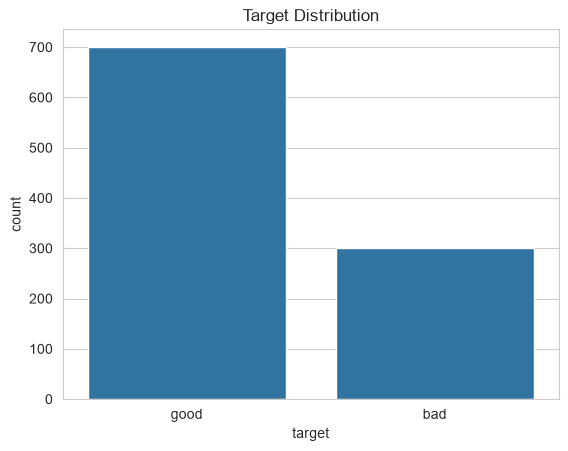

In [29]:
print(df['target'].value_counts(normalize=True))
sns.countplot(data=df,x='target')
plt.title('Target Distribution')
plt.show()

In [30]:
df.describe()

,month_duration,credit_amount,payment_to_income_ratio,residence_since,age,n_credits,n_guarantors
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


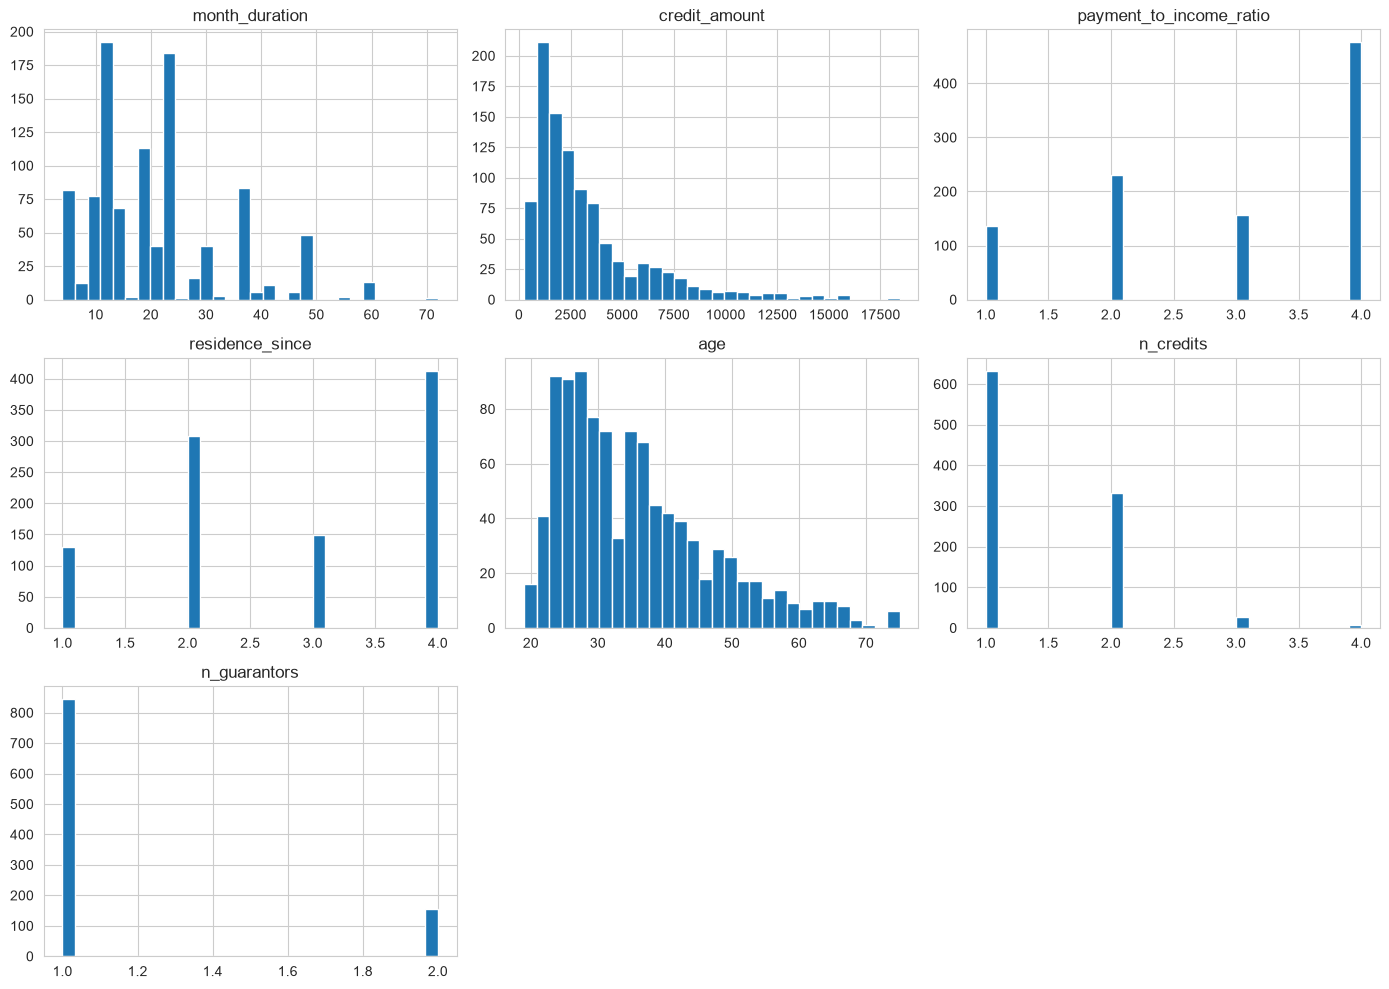

In [31]:
numerical_features=df.select_dtypes(include=[np.number]).columns.drop('target',errors='ignore')
df[numerical_features].hist(figsize=(14,10),bins=30)
plt.tight_layout()
plt.show()

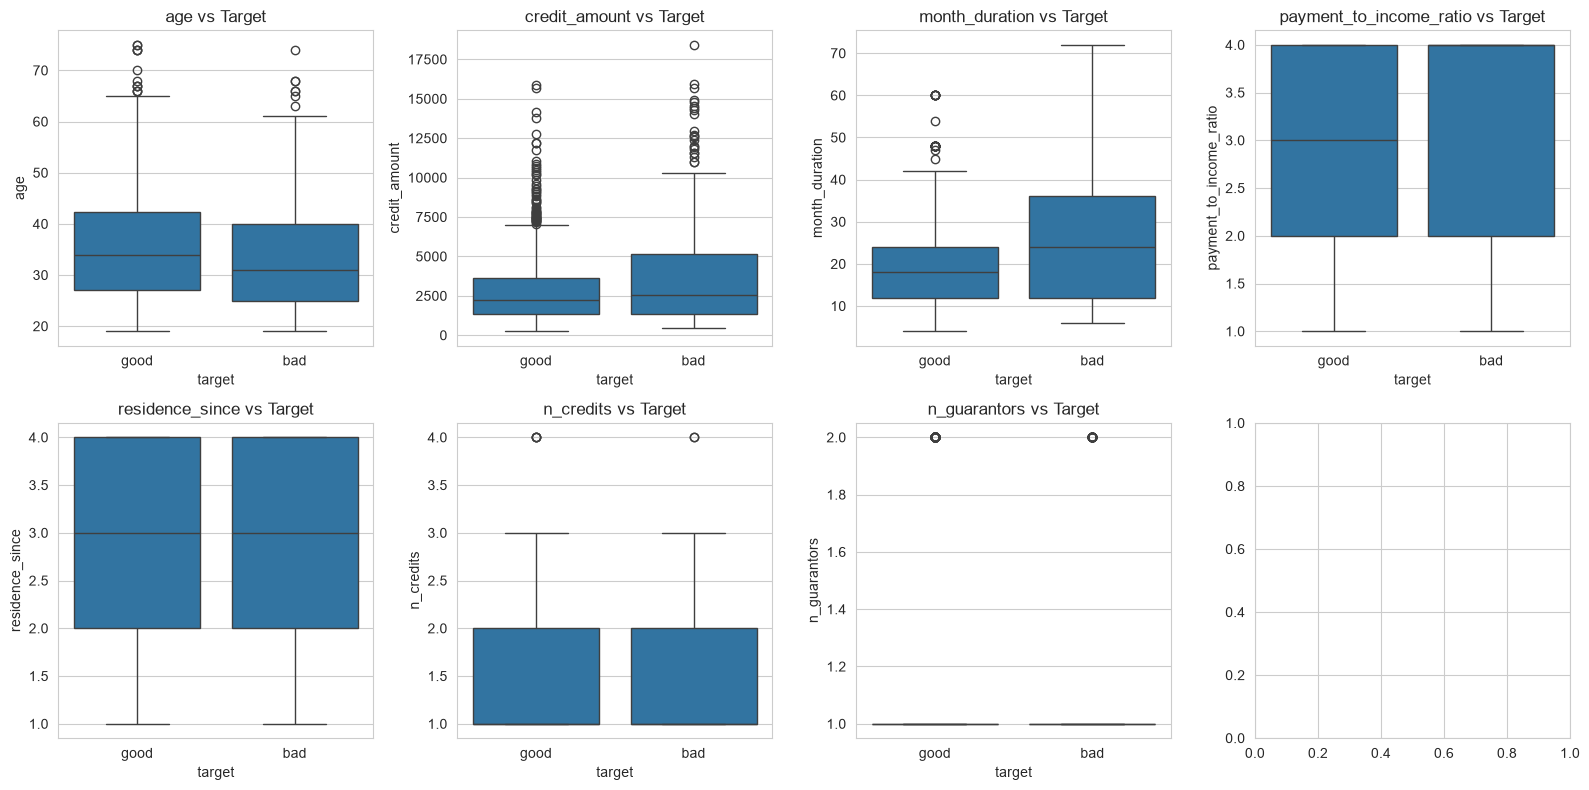

In [21]:
fig,axes=plt.subplots(2,4,figsize=(16,8))
compare_features=['age','credit_amount','month_duration','payment_to_income_ratio','residence_since','n_credits','n_guarantors']
compare_features=[f for f in compare_features if f in df.columns]
for ax,feature in zip(axes.ravel(),compare_features):
    sns.boxplot(data=df,x='target',y=feature,ax=ax)
    ax.set_title(f'{feature} vs Target')
plt.tight_layout()
plt.show()

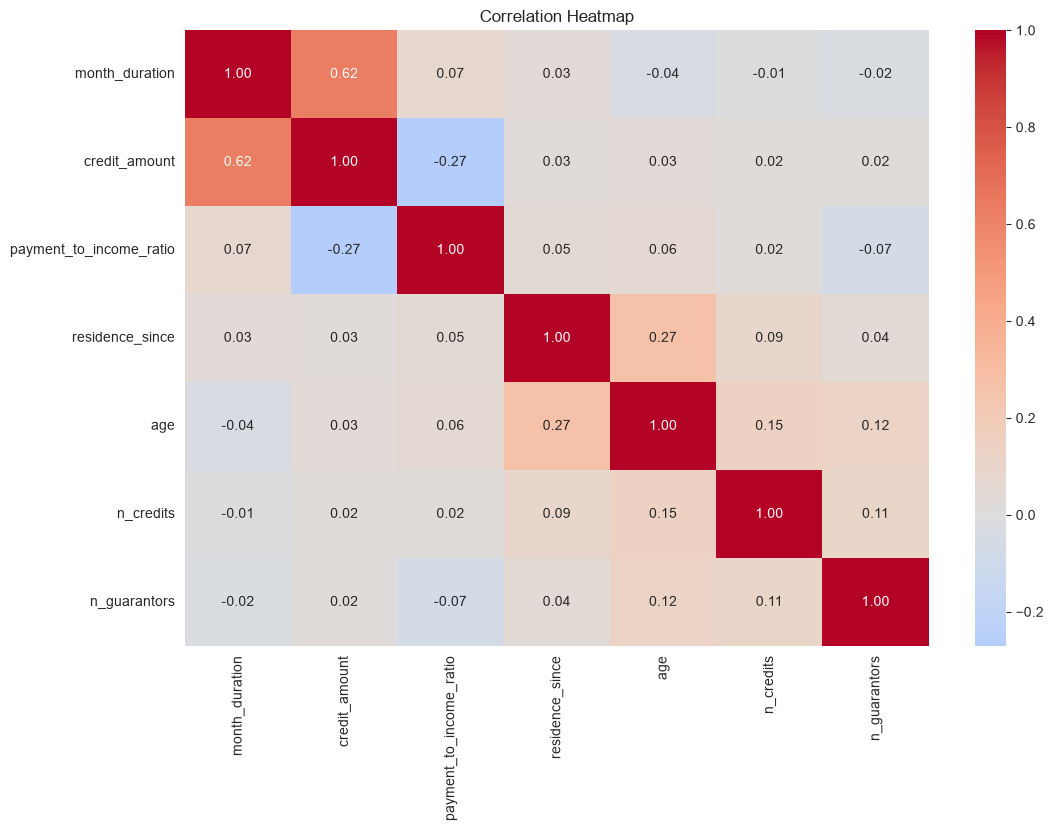

In [32]:
plt.figure(figsize=(12,8))
corr=df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr,annot=True,fmt='.2f',cmap='coolwarm',center=0)
plt.title('Correlation Heatmap')
plt.show()